## Graphical Analysis


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [6]:
detail_frequency = pd.read_csv("bikeshare/detail_frequency.csv")
weather_frequency = pd.read_csv("bikeshare/weather_frequency.csv")

In [7]:
weather_frequency.head()

,date,station_name,pickup_counts,dropoff_counts,city_name,tempmax,tempmin,temp,feelslikemax,feelslikemin,...,solarradiation,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon
0,2023-05-01,10th & E St NW,33,45.0,"Washington,DC,USA",16.0,9.9,13.7,16.0,8.2,...,90.0,7.8,3,10.0,2023-05-01T06:10:34,2023-05-01T20:00:36,0.37,"Rain, Partially cloudy",Partly cloudy throughout the day with late aft...,rain
1,2023-05-01,10th & G St NW,26,26.0,"Washington,DC,USA",16.0,9.9,13.7,16.0,8.2,...,90.0,7.8,3,10.0,2023-05-01T06:10:34,2023-05-01T20:00:36,0.37,"Rain, Partially cloudy",Partly cloudy throughout the day with late aft...,rain
2,2023-05-01,10th & H St NE,15,22.0,"Washington,DC,USA",16.0,9.9,13.7,16.0,8.2,...,90.0,7.8,3,10.0,2023-05-01T06:10:34,2023-05-01T20:00:36,0.37,"Rain, Partially cloudy",Partly cloudy throughout the day with late aft...,rain
3,2023-05-01,10th & K St NW,45,34.0,"Washington,DC,USA",16.0,9.9,13.7,16.0,8.2,...,90.0,7.8,3,10.0,2023-05-01T06:10:34,2023-05-01T20:00:36,0.37,"Rain, Partially cloudy",Partly cloudy throughout the day with late aft...,rain
4,2023-05-01,10th & Monroe St NE,7,10.0,"Washington,DC,USA",16.0,9.9,13.7,16.0,8.2,...,90.0,7.8,3,10.0,2023-05-01T06:10:34,2023-05-01T20:00:36,0.37,"Rain, Partially cloudy",Partly cloudy throughout the day with late aft...,rain


### Temporal Trends


To understand overall demand, we first focus on temporal patterns in bike rentals, analyzing both monthly and weekly trends.


#### Monthly Rental Counts and Average Temperature


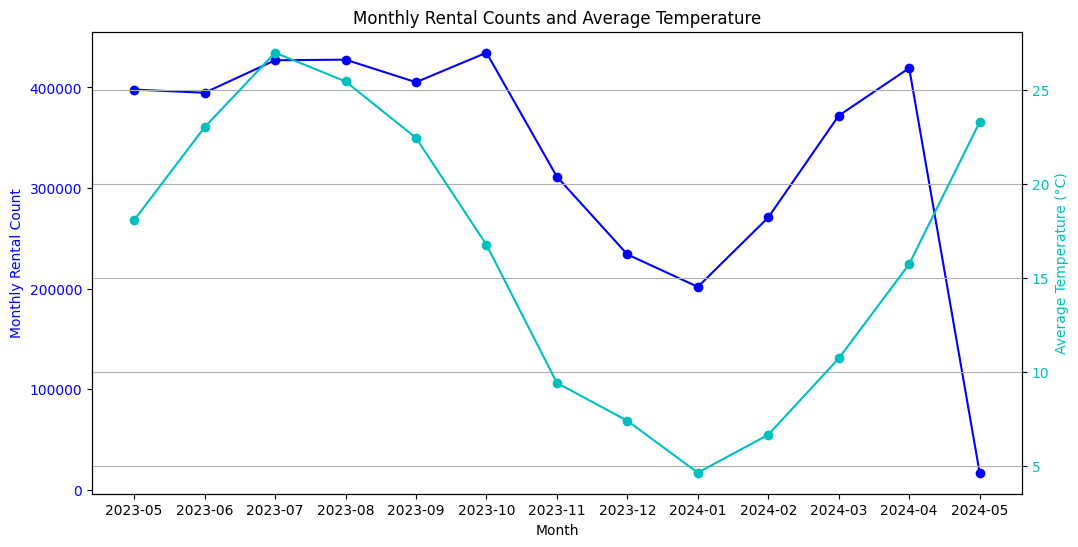

In [9]:
detail_frequency["started_day"] = pd.to_datetime(detail_frequency["started_day"])
detail_frequency["year_month"] = detail_frequency["started_day"].dt.to_period("M")
monthly_rentals = detail_frequency.groupby("year_month").size()
weather_frequency["date"] = pd.to_datetime(weather_frequency["date"])
weather_frequency["year_month"] = weather_frequency["date"].dt.to_period("M")
monthly_weather = (
    weather_frequency.groupby(["year_month", "icon"]).size().unstack(fill_value=0)
)

monthly_data = (
    weather_frequency.groupby("year_month")
    .agg({"pickup_counts": "sum", "temp": "mean"})
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel("Month")
ax1.set_ylabel("Monthly Rental Count", color="b")
ax1.plot(
    monthly_data["year_month"].astype(str),
    monthly_data["pickup_counts"],
    color="b",
    marker="o",
)
ax1.tick_params(axis="y", labelcolor="b")

ax2 = ax1.twinx()
ax2.set_ylabel("Average Temperature (°C)", color="c")
ax2.plot(
    monthly_data["year_month"].astype(str), monthly_data["temp"], color="c", marker="o"
)
ax2.tick_params(axis="y", labelcolor="c")

plt.title("Monthly Rental Counts and Average Temperature")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

This plot shows the total bike rentals for each month alongside the average monthly temperature. By displaying rentals and temperature on separate y-axes, we can observe the relationship between seasonal temperature changes and bike usage.
We can see higher rentals in warmer months, revealing the seasonal nature of bike-sharing demand. Rental counts peaking during warmer months and declining in colder months.


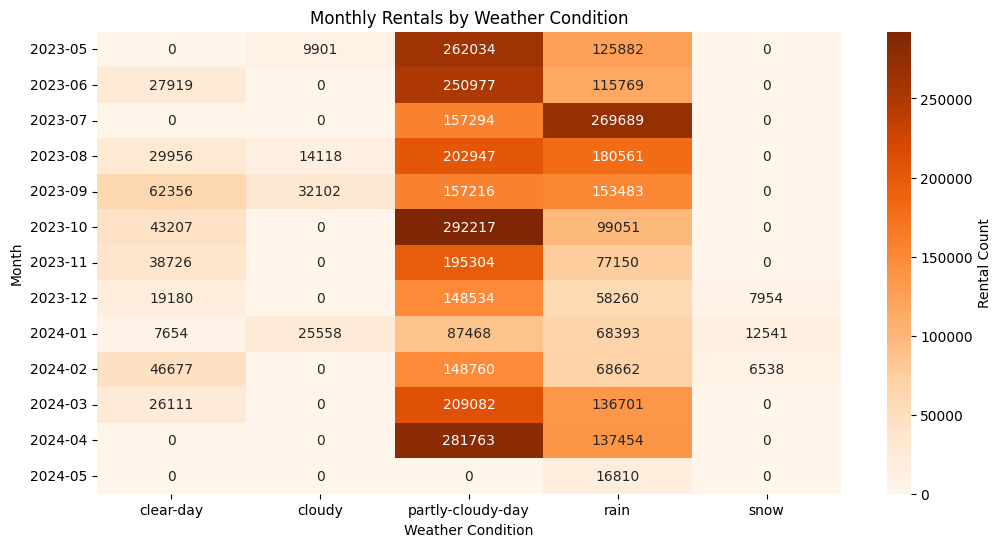

In [10]:
weather_frequency["year_month"] = weather_frequency["date"].dt.to_period("M")
monthly_weather_rentals = (
    weather_frequency.groupby(["year_month", "icon"])["pickup_counts"]
    .sum()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    monthly_weather_rentals,
    annot=True,
    fmt="d",
    cmap="Oranges",
    cbar_kws={"label": "Rental Count"},
)
plt.xlabel("Weather Condition")
plt.ylabel("Month")
plt.title("Monthly Rentals by Weather Condition")
plt.show()


People rent the most bikes on partly cloudy and clear days, especially in warmer months like April, May, August, and October. Rentals go down when it rains, but there are still a fair number of rentals in certain months.People are more likely to rent bikes on clear and partly cloudy days, and rentals drop on rainy days and even more on snowy days.


#### Weekly Trends in Rentals


/var/folders/p5/grng0bpx24988f1v2318bx6w0000gn/T/ipykernel_90614/2134913529.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekly_trends = detail_frequency.groupby("day_of_week").size()


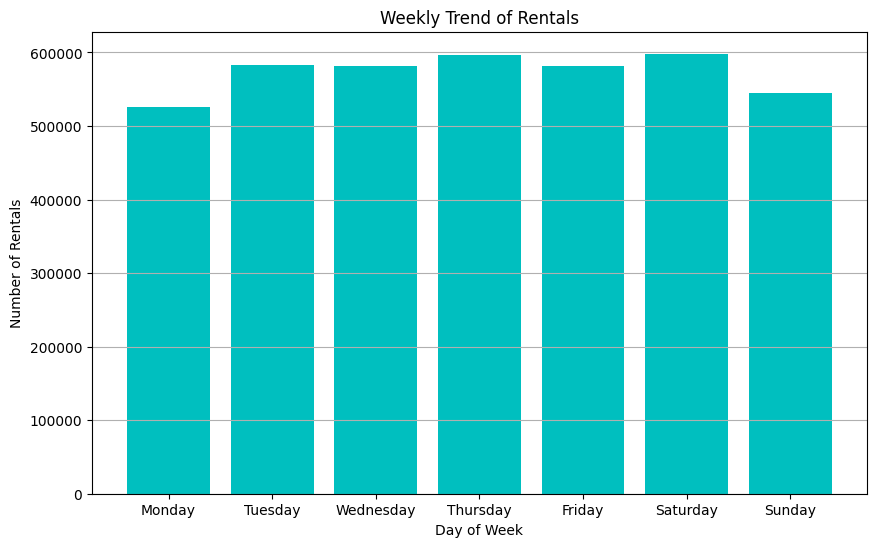

In [12]:
detail_frequency["started_at"] = pd.to_datetime(detail_frequency["started_at"])
detail_frequency["day_of_week"] = detail_frequency["started_at"].dt.day_name()
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
detail_frequency["day_of_week"] = pd.Categorical(
    detail_frequency["day_of_week"], categories=day_order, ordered=True
)
weekly_trends = detail_frequency.groupby("day_of_week").size()


plt.figure(figsize=(10, 6))
plt.bar(weekly_trends.index, weekly_trends, color="c")
plt.title("Weekly Trend of Rentals")
plt.xlabel("Day of Week")
plt.ylabel("Number of Rentals")
plt.grid(axis="y")
plt.show()


The relatively even distribution of rentals from Tuesday to Saturday implies that biking is consistently popular on these days. There is a noticeable drop in rentals on Sunday and Monday compared to the other days.


#### Hourly Trend


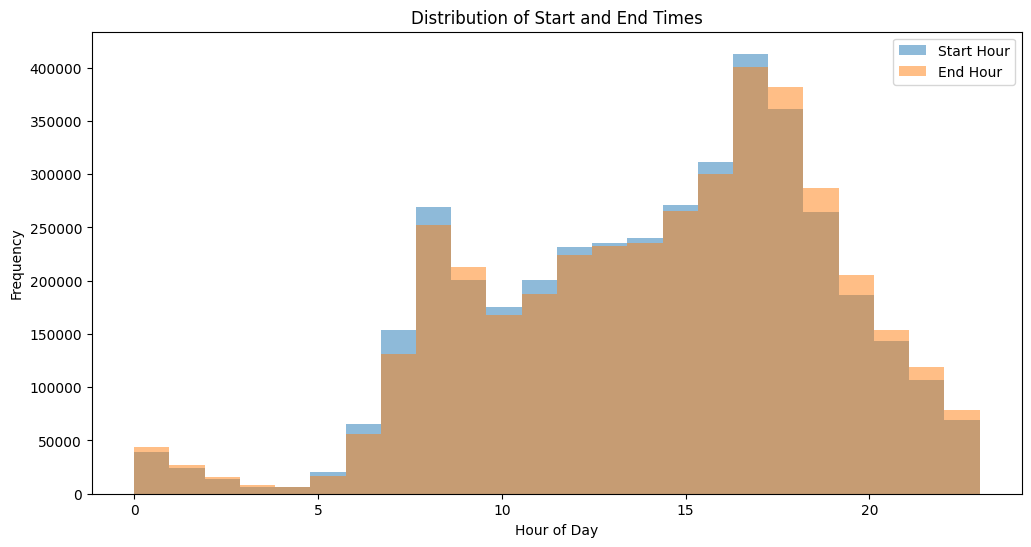

In [13]:
detail_frequency["started_at"] = pd.to_datetime(detail_frequency["started_at"])
detail_frequency["ended_at"] = pd.to_datetime(detail_frequency["ended_at"])

detail_frequency["start_hour"] = detail_frequency["started_at"].dt.hour
detail_frequency["end_hour"] = detail_frequency["ended_at"].dt.hour

plt.figure(figsize=(12, 6))
plt.hist(detail_frequency["start_hour"], bins=24, alpha=0.5, label="Start Hour")
plt.hist(detail_frequency["end_hour"], bins=24, alpha=0.5, label="End Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Frequency")
plt.title("Distribution of Start and End Times")
plt.legend()
plt.show()

This chart shows that bike rentals peak during morning (8-9 AM) and evening (4-6 PM) rush hours, suggesting high use for commuting. There’s moderate activity in the midday, likely for leisure, and minimal rentals late at night.


#### Start Station Activity by Time of Day


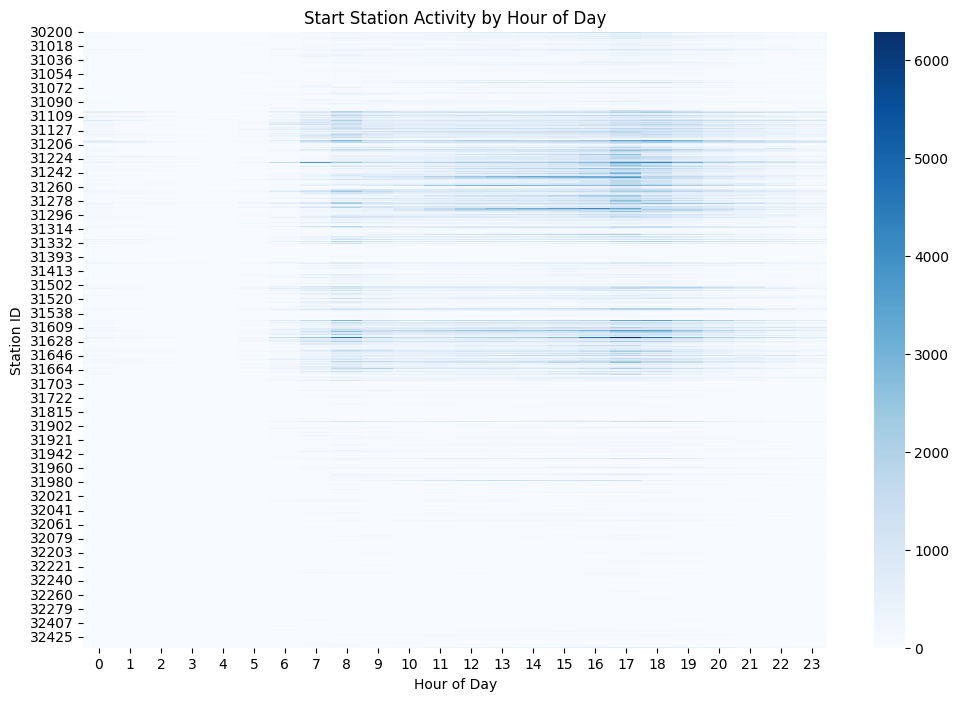

In [14]:
detail_frequency["start_hour"] = detail_frequency["started_at"].dt.hour
station_activity = (
    detail_frequency.groupby(["start_station_id", "start_hour"])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12, 8))
sns.heatmap(station_activity, cmap="Blues")
plt.xlabel("Hour of Day")
plt.ylabel("Station ID")
plt.title("Start Station Activity by Hour of Day")
plt.show()

Certain stations have consistently higher activity, as shown by the darker bands. These stations likely serve as central or high-demand locations in the network.A cross all stations, activity is minimal from 10 PM to 5 AM, which is expected due to reduced travel during these hours.


### Comparison of Start and End Locations

/Users/yidanchang/Desktop/FALL2024/SI618/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


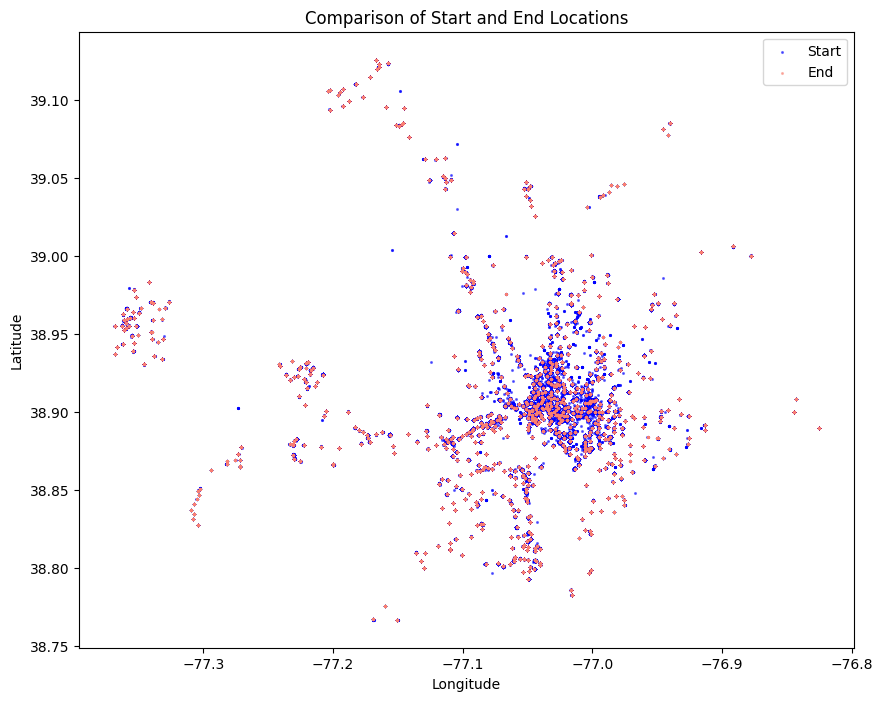

In [15]:
plt.figure(figsize=(10, 8))
plt.scatter(
    detail_frequency["start_lng"],
    detail_frequency["start_lat"],
    alpha=0.5,
    color="blue",
    label="Start",
    s=1.5,
)
plt.scatter(
    detail_frequency["end_lng"],
    detail_frequency["end_lat"],
    alpha=0.5,
    color="salmon",
    label="End",
    s=1.5,
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Comparison of Start and End Locations")
plt.legend()
plt.show()

The majority of start and end points are clustered around a central area, suggesting a high-demand zone. While most start and end points overlap in the central area, there are several points on the outskirts, indicating that some users start or end their rentals in less populated areas. This could represent people commuting from outer areas to the central area.


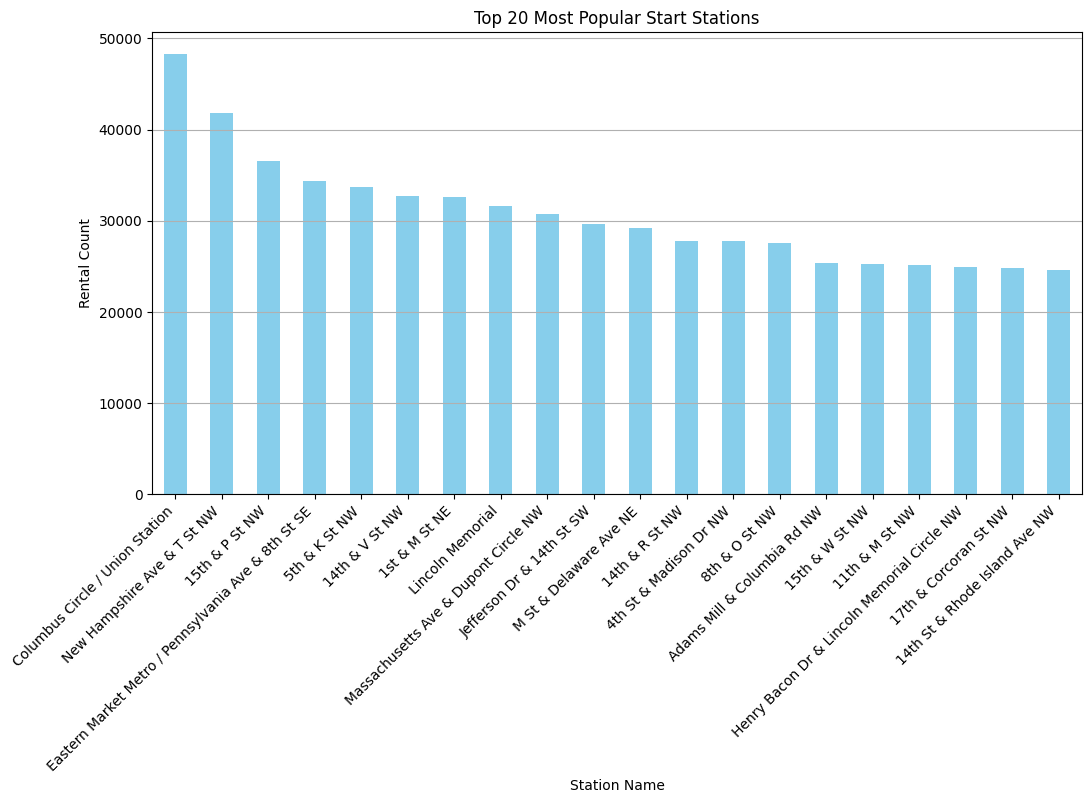

In [16]:
top_stations = detail_frequency["start_station_name"].value_counts().nlargest(20)
plt.figure(figsize=(12, 6))
top_stations.plot(kind="bar", color="skyblue")
plt.xlabel("Station Name")
plt.ylabel("Rental Count")
plt.title("Top 20 Most Popular Start Stations")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()


This bar plot lists the top 20 stations with the highest rental counts. This gives an overview of the most popular start points in the network.


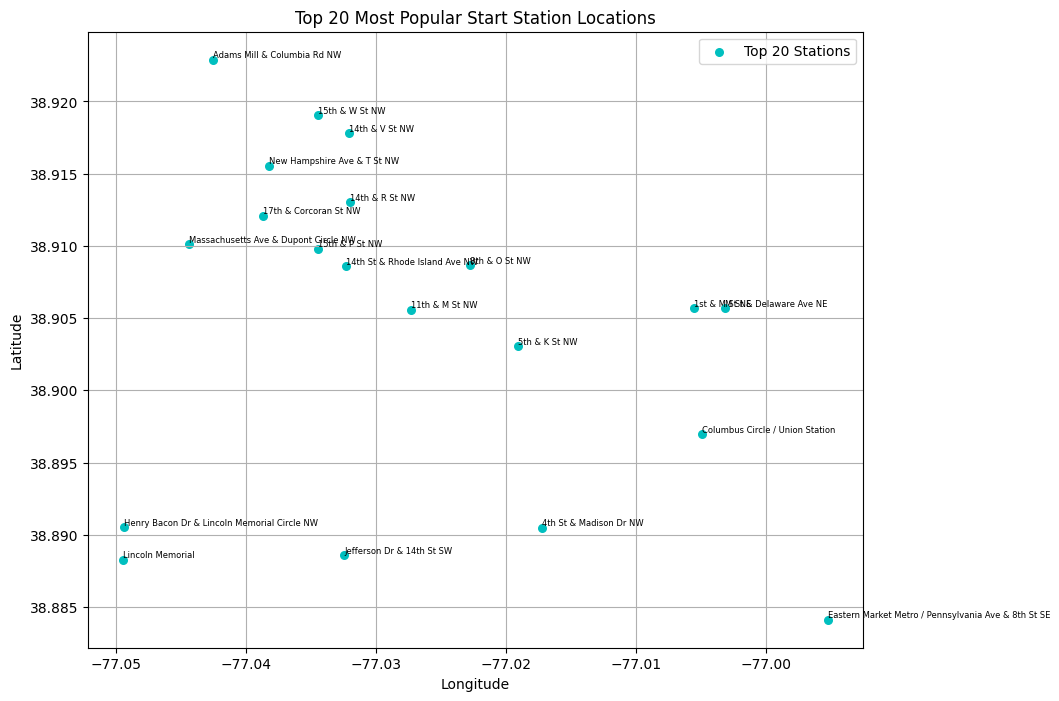

In [17]:
top_stations = detail_frequency["start_station_name"].value_counts().nlargest(20).index
top_stations_data = detail_frequency[
    detail_frequency["start_station_name"].isin(top_stations)
]
station_locations = top_stations_data.groupby("start_station_name")[
    ["start_lat", "start_lng"]
].mean()


plt.figure(figsize=(10, 8))
plt.scatter(
    station_locations["start_lng"],
    station_locations["start_lat"],
    color="c",
    s=30,
    label="Top 20 Stations",
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Top 20 Most Popular Start Station Locations")
plt.grid(True)

for station, row in station_locations.iterrows():
    plt.text(row["start_lng"], row["start_lat"], station, fontsize=6, va="bottom")
plt.legend()
plt.show()


This plot shows the top 20 most popular bike start stations, mostly clustered in busy areas of the city. Many are near popular landmarks like the Lincoln Memorial and Union Station, indicating that both commuters and tourists frequently use these locations. Key streets like 14th St NW and Massachusetts Ave NW have several high-demand stations, suggesting these areas are major bike routes.


### User Behavior

This section analyzes bike type preferences and explores how rental duration varies across different user segments.

#### Bike Type Usage


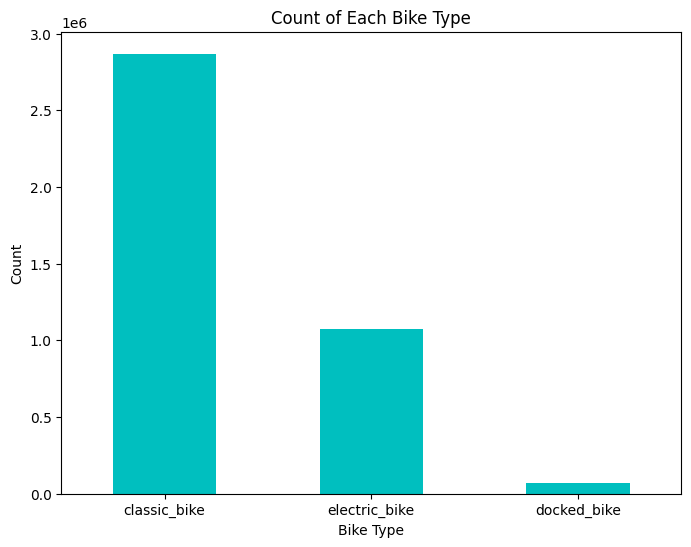

In [18]:
plt.figure(figsize=(8, 6))
detail_frequency["rideable_type"].value_counts().plot(kind="bar", color="c")
plt.xlabel("Bike Type")
plt.ylabel("Count")
plt.title("Count of Each Bike Type")
plt.xticks(rotation=0)
plt.show()

Classic bikes are the most popular, with nearly 3 million rentals, indicating they’re the primary choice for users. Electric bikes are used less frequently than classic bikes but still popular, while docked bikes are the least used.


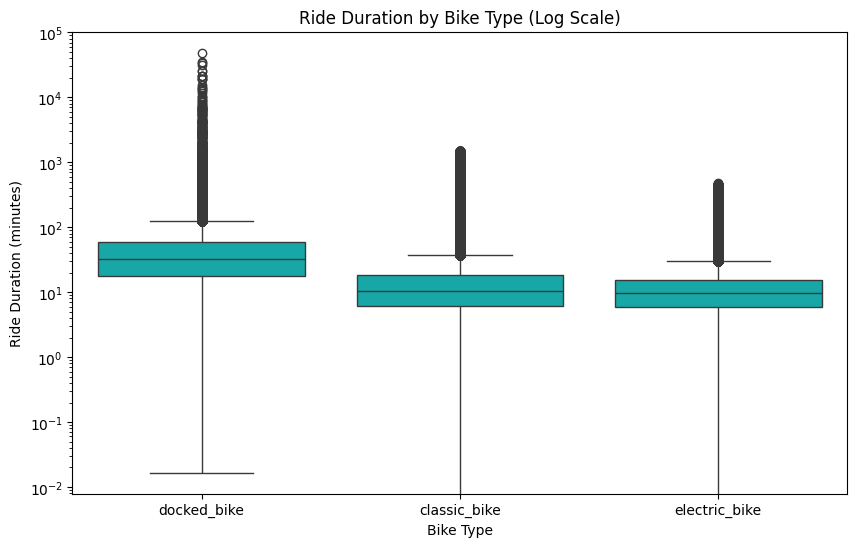

In [19]:
detail_frequency["ride_duration"] = (
    detail_frequency["ended_at"] - detail_frequency["started_at"]
).dt.total_seconds() / 60
plt.figure(figsize=(10, 6))
sns.boxplot(x="rideable_type", y="ride_duration", data=detail_frequency, color="c")
plt.yscale("log")
plt.title("Ride Duration by Bike Type (Log Scale)")
plt.xlabel("Bike Type")
plt.ylabel("Ride Duration (minutes)")
plt.show()


Docked bikes have the largest range of ride durations, with several outliers showing extremely long rides (over 1000 minutes). This suggests some docked bikes might not have been properly returned or checked in. Classic and electric bikes show shorter, more consistent ride durations compared to docked bikes. Most rides fall between 10 and 100 minutes, indicating these bikes are generally used for typical, short trips. The median ride duration for each bike type is around 10 to 30 minutes, which aligns with average trip times for shared bike systems.

#### Distribution of Ride Duration Across User Segments


/Users/yidanchang/Desktop/FALL2024/SI618/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


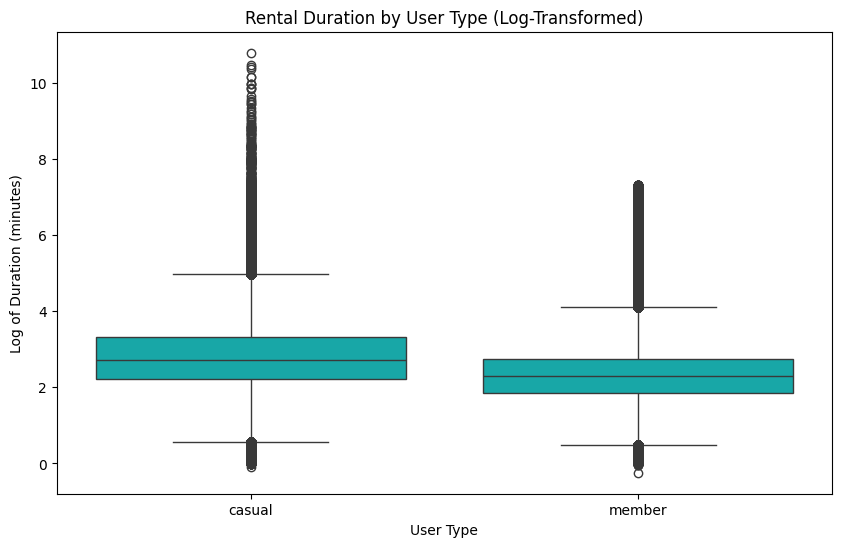

In [22]:
detail_frequency["duration"] = (
    detail_frequency["ended_at"] - detail_frequency["started_at"]
).dt.total_seconds() / 60
detail_frequency["is_overnight"] = (
    detail_frequency["ended_at"].dt.date > detail_frequency["started_at"].dt.date
)
overnight_count = detail_frequency["is_overnight"].sum()
same_day_rentals = detail_frequency[~detail_frequency["is_overnight"]]

detail_frequency['log_duration'] = np.log1p(detail_frequency['duration'])

plt.figure(figsize=(10, 6))
sns.boxplot(data=detail_frequency, x="member_casual", y="log_duration", color='c')
plt.title("Rental Duration by User Type (Log-Transformed)")
plt.xlabel("User Type")
plt.ylabel("Log of Duration (minutes)")
plt.show()

The data shows that casual users generally have longer ride durations compared to members, who tend to have shorter, more consistent trip times. Both casual users and members have some outliers with very long durations, though they are more common among casual users. These could be due to trips that were not properly ended in the system.